In [18]:
import re, json
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (confusion_matrix, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve)

SEED = 42
pd.set_option('display.width', 160)

In [19]:
FEATURES = [
    "response_time", "error_count", "downtime", "users_affected",
    "previous_similar", "customer_priority", "ticket_age", "severity_indicators",
]
import numpy as np
import pandas as pd

PRIORITIES = ["Low", "Medium", "High"]

SEVERITY_PHRASES = ["crash", "data loss", "outage", "cannot login", "corrupt"]
MILD_PHRASES = ["slow", "delay", "minor glitch", "cosmetic issue"]


def _render_text(row: dict, rng: np.random.Generator) -> str:
    parts = [f"The application took {row['response_time']:.1f} sec to respond."]
    if row["error_count"] > 0:
        parts.append(f"We saw {int(row['error_count'])} errors in the logs.")
    if row["users_affected"] > 0:
        parts.append(f"About {int(row['users_affected'])} users are affected.")
    if row["downtime"] > 0:
        parts.append(f"There was {int(round(row['downtime']))} min of downtime.")
    if row["previous_similar"] > 0:
        parts.append(f"This is similar to {int(row['previous_similar'])} previous tickets.")
    k = int(row["severity_indicators"])
    sev = list(rng.choice(SEVERITY_PHRASES, size=min(k, len(SEVERITY_PHRASES)), replace=False))
    mild = list(rng.choice(MILD_PHRASES, size=int(rng.integers(0, 2)), replace=False))
    words = sev + mild
    rng.shuffle(words)
    if words:
        parts.append("Symptoms: " + ", ".join(words) + ".")
    return " ".join(parts)


def generate(n: int = 8000, escalation_rate: float = 0.25, seed: int = 42,
             missing_rate: float = 0.03, with_text: bool = True) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    y = (rng.random(n) < escalation_rate).astype(int)

    def lognorm(mu0: float, mu1: float, sigma: float) -> np.ndarray:
        mu = np.where(y == 1, mu1, mu0)
        return np.exp(rng.normal(mu, sigma))

    # Wide sigmas -> substantial class overlap.
    response_time = lognorm(np.log(2.0), np.log(3.4), 0.80)                   # seconds
    error_count = np.round(lognorm(np.log(3.0), np.log(6.5), 1.0)).clip(0)
    downtime = np.round(lognorm(np.log(4.0), np.log(10.0), 1.2)).clip(0)     # minutes
    users_affected = np.round(lognorm(np.log(10.0), np.log(28.0), 1.15)).clip(1)
    previous_similar = rng.poisson(np.where(y == 1, 2.3, 1.5))
    ticket_age = np.round(lognorm(np.log(2.0), np.log(2.7), 0.9), 1)          # days

    p_high = np.where(y == 1, 0.38, 0.18)
    p_low = np.where(y == 1, 0.18, 0.34)
    u = rng.random(n)
    prio = np.where(u < p_low, "Low", np.where(u < 1 - p_high, "Medium", "High"))

    severity = np.clip(rng.poisson(np.where(y == 1, 1.2, 0.7)), 0, 5)

    df = pd.DataFrame({
        "response_time": response_time.round(2),
        "error_count": error_count.astype(int),
        "downtime": downtime.astype(int),
        "users_affected": users_affected.astype(int),
        "previous_similar": previous_similar,
        "customer_priority": prio,
        "ticket_age": ticket_age,
        "severity_indicators": severity,
    })

    if with_text:
        df["text"] = [_render_text(r, rng) for r in df.to_dict("records")]

    # Missing values in numeric structured features (never the label).
    if missing_rate > 0:
        for col in ["response_time", "error_count", "downtime", "users_affected", "ticket_age"]:
            mask = rng.random(n) < missing_rate
            df[col] = df[col].astype("float")
            df.loc[mask, col] = np.nan

    df["escalate"] = y
    return df


In [20]:
df = generate(n=8000, escalation_rate=0.25, seed=SEED)
print(df.shape, '| escalation rate', f'{df.escalate.mean():.1%}')
print('missing cells:', int(df.isna().sum().sum()))
df.head()

(8000, 10) | escalation rate 25.6%
missing cells: 1226


,response_time,error_count,downtime,users_affected,previous_similar,customer_priority,ticket_age,severity_indicators,text,escalate
0,0.73,3.0,3.0,3.0,2,Medium,3.0,0,The application took 0.7 sec to respond. We sa...,0
1,2.74,1.0,2.0,44.0,1,Low,1.6,2,The application took 2.7 sec to respond. We sa...,0
2,2.19,1.0,4.0,7.0,2,Medium,3.1,0,The application took 2.2 sec to respond. We sa...,0
3,2.70,1.0,20.0,20.0,3,Medium,6.8,1,The application took 2.7 sec to respond. We sa...,0
4,4.96,5.0,18.0,21.0,1,High,5.0,1,The application took 5.0 sec to respond. We sa...,1


In [21]:
df.describe().T[['count','mean','std','min','50%','max']].round(2)

,count,mean,std,min,50%,max
response_time,7772.0,3.25,3.45,0.09,2.23,94.14
error_count,7746.0,6.53,8.75,0.00,4.00,132.00
downtime,7751.0,11.60,21.85,0.00,5.00,480.00
users_affected,7747.0,28.64,58.94,1.00,12.00,1526.00
previous_similar,8000.0,1.71,1.35,0.00,2.00,8.00
ticket_age,7758.0,3.34,3.83,0.10,2.20,60.60
severity_indicators,8000.0,0.83,0.93,0.00,1.00,5.00
escalate,8000.0,0.26,0.44,0.00,0.00,1.00


In [22]:
import numpy as np


def _logsumexp(a: np.ndarray, axis: int = 1) -> np.ndarray:
    m = a.max(axis=axis, keepdims=True)
    return (m + np.log(np.exp(a - m).sum(axis=axis, keepdims=True))).squeeze(axis)


class GDA:
    def __init__(self, shared_cov: bool = True, reg: float = 1e-6):
        self.shared_cov = shared_cov
        self.reg = reg

    def fit(self, X: np.ndarray, y: np.ndarray) -> "GDA":
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n, d = X.shape
        K = len(self.classes_)

        self.priors_ = np.array([(y == k).mean() for k in self.classes_])      # phi
        self.means_ = np.array([X[y == k].mean(axis=0) for k in self.classes_])  # mu_k

        scatters = []
        for i, k in enumerate(self.classes_):
            Xc = X[y == k] - self.means_[i]
            scatters.append(Xc.T @ Xc)

        if self.shared_cov:
            pooled = sum(scatters) / n
            self.covs_ = np.array([pooled + self.reg * np.eye(d)] * K)
        else:
            counts = [(y == k).sum() for k in self.classes_]
            self.covs_ = np.array(
                [s / c + self.reg * np.eye(d) for s, c in zip(scatters, counts)]
            )

        self.inv_covs_ = np.array([np.linalg.inv(c) for c in self.covs_])
        self.logdets_ = np.array([np.linalg.slogdet(c)[1] for c in self.covs_])
        self.cond_ = float(np.linalg.cond(self.covs_[0]))  # diagnostic: singularity check
        return self

    def _joint_log_likelihood(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        d = X.shape[1]
        out = np.empty((X.shape[0], len(self.classes_)))
        for i in range(len(self.classes_)):
            diff = X - self.means_[i]
            maha = np.einsum("nd,de,ne->n", diff, self.inv_covs_[i], diff)
            out[:, i] = np.log(self.priors_[i]) - 0.5 * (
                d * np.log(2 * np.pi) + self.logdets_[i] + maha
            )
        return out

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        jll = self._joint_log_likelihood(X)
        return np.exp(jll - _logsumexp(jll)[:, None])

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """Binary: threshold applies to P(class = classes_[1])."""
        if len(self.classes_) == 2:
            p = self.predict_proba(X)[:, 1]
            return np.where(p >= threshold, self.classes_[1], self.classes_[0])
        return self.classes_[np.argmax(self._joint_log_likelihood(X), axis=1)]


In [23]:
import re
from dataclasses import dataclass, field

import numpy as np
import pandas as pd

FEATURES = [
    "response_time", "error_count", "downtime", "users_affected",
    "previous_similar", "customer_priority", "ticket_age", "severity_indicators",
]
LOG_COLS = ["response_time", "error_count", "downtime", "users_affected",
            "previous_similar", "ticket_age"]
PRIORITY_MAP = {"low": 0, "medium": 1, "med": 1, "high": 2}

# ---------------------------------------------------------------- text -> features
SEVERITY_KEYWORDS = [
    "crash", "data loss", "outage", "cannot login", "can't login", "corrupt",
    "down", "unresponsive", "timeout", "failed", "critical", "security", "breach",
]

_NUM = r"(\d+(?:\.\d+)?)"
_PATTERNS = {
    "response_time": re.compile(_NUM + r"\s*(?:sec|secs|seconds|s)\b", re.I),
    "error_count": re.compile(_NUM + r"\s*errors?\b", re.I),
    "users_affected": re.compile(_NUM + r"\s*(?:users?|customers?)\b", re.I),
    "previous_similar": re.compile(_NUM + r"\s*(?:previous|prior|earlier)\s+(?:similar\s+)?tickets?\b", re.I),
}
_DOWNTIME_MIN = re.compile(_NUM + r"\s*(?:min|mins|minutes?)\b(?:\s+of)?\s+downtime", re.I)
_DOWNTIME_HR = re.compile(_NUM + r"\s*(?:h|hr|hrs|hours?)\b(?:\s+of)?\s+downtime", re.I)


def count_severity(text: str) -> int:
    t = text.lower()
    return sum(1 for kw in SEVERITY_KEYWORDS if re.search(r"\b" + re.escape(kw) + r"\b", t))


def extract_features(text: str, customer_priority: str = "Medium", ticket_age: float = np.nan) -> dict:
    """Regex + keyword extractor for a raw ticket body.

    Priority and age are ticket metadata (not in the free text), so they are passed in.
    Fields not found in the text come back as NaN; the preprocessor imputes them.
    """
    out: dict = {k: np.nan for k in FEATURES}
    for name, pat in _PATTERNS.items():
        m = pat.search(text)
        if m:
            out[name] = float(m.group(1))
    m = _DOWNTIME_MIN.search(text)
    if m:
        out["downtime"] = float(m.group(1))
    else:
        m = _DOWNTIME_HR.search(text)
        if m:
            out["downtime"] = float(m.group(1)) * 60.0
    out["severity_indicators"] = count_severity(text)
    out["customer_priority"] = customer_priority
    out["ticket_age"] = ticket_age
    return out


# ---------------------------------------------------------------- preprocessing
@dataclass
class Preprocessor:
    """Impute -> log1p skewed columns -> ordinal-encode priority -> standardize.

    All statistics are learned in fit() (train split only) to avoid leakage.
    """
    log_cols: list = field(default_factory=lambda: list(LOG_COLS))
    columns: list = field(default_factory=lambda: list(FEATURES))

    def _prep(self, df: pd.DataFrame) -> pd.DataFrame:
        X = df[self.columns].copy()
        X["customer_priority"] = (
            X["customer_priority"].astype(str).str.lower().map(PRIORITY_MAP)
        )
        for c in self.columns:
            X[c] = pd.to_numeric(X[c], errors="coerce")
        return X

    def fit(self, df: pd.DataFrame) -> "Preprocessor":
        X = self._prep(df)
        self.medians_ = X.median()
        X = X.fillna(self.medians_)
        X[self.log_cols] = np.log1p(X[self.log_cols].clip(lower=0))
        self.mean_ = X.mean()
        self.std_ = X.std(ddof=0).replace(0, 1.0)
        return self

    def transform(self, df: pd.DataFrame) -> np.ndarray:
        X = self._prep(df).fillna(self.medians_)
        X[self.log_cols] = np.log1p(X[self.log_cols].clip(lower=0))
        return ((X - self.mean_) / self.std_).to_numpy(dtype=float)

    def fit_transform(self, df: pd.DataFrame) -> np.ndarray:
        return self.fit(df).transform(df)


In [24]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)



def metrics_at(y_true, proba, threshold: float = 0.5) -> dict:
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": round(float(threshold), 3),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def tune_threshold(y_val, proba_val, min_recall: float = 0.90) -> float:
    """Pick the threshold that maximises precision subject to recall >= min_recall.

    Missing a critical ticket costs more than a false alarm, so recall is the constraint.
    Falls back to the max-F1 threshold if the recall target is unreachable.
    """
    grid = np.linspace(0.02, 0.98, 97)
    best_t, best_p = None, -1.0
    for t in grid:
        m = metrics_at(y_val, proba_val, t)
        if m["recall"] >= min_recall and m["precision"] > best_p:
            best_t, best_p = t, m["precision"]
    if best_t is None:
        best_t = max(grid, key=lambda t: metrics_at(y_val, proba_val, t)["f1"])
    return float(best_t)


def build_models(seed: int = 0) -> dict:
    return {
        "GDA (LDA, shared cov)": GDA(shared_cov=True),
        "GDA (QDA, per-class cov)": GDA(shared_cov=False),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=seed),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1),
    }


def compare_models(Xtr, ytr, Xva, yva, Xte, yte, min_recall: float = 0.90, seed: int = 0):
    """Fit every model on train, tune threshold on val, report on test."""
    rows, probas = [], {}
    for name, model in build_models(seed).items():
        model.fit(Xtr, ytr)
        p_va = model.predict_proba(Xva)[:, 1]
        p_te = model.predict_proba(Xte)[:, 1]
        t = tune_threshold(yva, p_va, min_recall)
        default = metrics_at(yte, p_te, 0.5)
        tuned = metrics_at(yte, p_te, t)
        rows.append({"model": name, "at_0.5": default, "tuned": tuned})
        probas[name] = p_te
    return rows, probas


In [25]:
train, tmp = train_test_split(df, test_size=0.30, stratify=df.escalate, random_state=SEED)
val, test = train_test_split(tmp, test_size=0.50, stratify=tmp.escalate, random_state=SEED)

pre = Preprocessor().fit(train)
Xtr, Xva, Xte = pre.transform(train), pre.transform(val), pre.transform(test)
ytr, yva, yte = train.escalate.to_numpy(), val.escalate.to_numpy(), test.escalate.to_numpy()
print(Xtr.shape, Xva.shape, Xte.shape)

(5600, 8) (1200, 8) (1200, 8)


In [26]:
# Why log-transform? Skewness before -> after
raw_cols = ['response_time','error_count','downtime','users_affected']
raw = train[raw_cols].fillna(train[raw_cols].median())
pd.DataFrame({'raw': raw.apply(skew), 'log1p': np.log1p(raw).apply(skew)}).round(2)

,raw,log1p
response_time,6.05,0.78
error_count,4.41,0.48
downtime,5.56,0.56
users_affected,10.67,0.46


In [27]:
rows, probas = compare_models(Xtr, ytr, Xva, yva, Xte, yte, min_recall=0.90, seed=SEED)

out = []
for r in rows:
    for tag, m in (("0.5", r["at_0.5"]), ("tuned", r["tuned"])):
        out.append({"model": r["model"], "thr": tag, **{k: m[k] for k in ["threshold","precision","recall","f1","roc_auc","fn","fp"]}})
results = pd.DataFrame(out).round(3)
results

,model,thr,threshold,precision,recall,f1,roc_auc,fn,fp
0,"GDA (LDA, shared cov)",0.5,0.50,0.758,0.644,0.696,0.893,109,63
1,"GDA (LDA, shared cov)",tuned,0.12,0.468,0.908,0.618,0.893,28,316
2,"GDA (QDA, per-class cov)",0.5,0.50,0.722,0.621,0.668,0.878,116,73
3,"GDA (QDA, per-class cov)",tuned,0.11,0.447,0.902,0.598,0.878,30,341
4,Logistic Regression,0.5,0.50,0.761,0.644,0.697,0.893,109,62
5,Logistic Regression,tuned,0.13,0.466,0.915,0.617,0.893,26,321
6,Random Forest,0.5,0.50,0.757,0.601,0.670,0.875,122,59
7,Random Forest,tuned,0.18,0.448,0.886,0.595,0.875,35,334


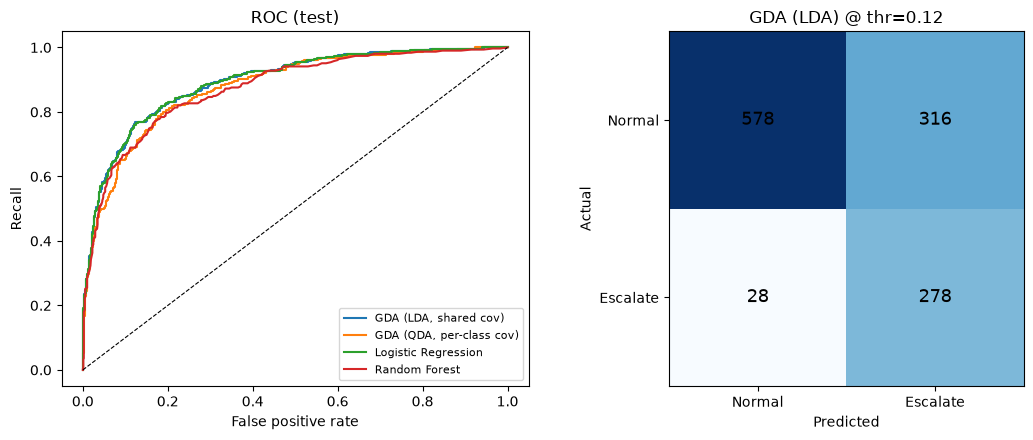

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(yte, p)
    ax[0].plot(fpr, tpr, label=name)
ax[0].plot([0,1],[0,1],'k--',lw=0.8)
ax[0].set(xlabel='False positive rate', ylabel='Recall', title='ROC (test)')
ax[0].legend(fontsize=8, loc='lower right')

lda = next(r for r in rows if r['model'].startswith('GDA (LDA'))['tuned']
cm = np.array([[lda['tn'], lda['fp']], [lda['fn'], lda['tp']]])
ax[1].imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    ax[1].text(j, i, str(v), ha='center', va='center', fontsize=13)
ax[1].set_xticks([0,1], ['Normal','Escalate']); ax[1].set_yticks([0,1], ['Normal','Escalate'])
ax[1].set(xlabel='Predicted', ylabel='Actual', title=f"GDA (LDA) @ thr={lda['threshold']}")
plt.tight_layout(); plt.show()

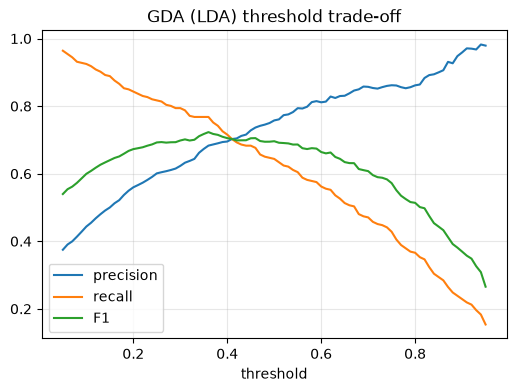

In [29]:
# Precision/recall trade-off across thresholds for GDA (LDA)
lda_model = GDA(shared_cov=True).fit(Xtr, ytr)
p = lda_model.predict_proba(Xte)[:, 1]
ts = np.linspace(0.05, 0.95, 91)
M = [metrics_at(yte, p, t) for t in ts]
plt.figure(figsize=(6,4))
plt.plot(ts, [m['precision'] for m in M], label='precision')
plt.plot(ts, [m['recall'] for m in M], label='recall')
plt.plot(ts, [m['f1'] for m in M], label='F1')
plt.xlabel('threshold'); plt.legend(); plt.title('GDA (LDA) threshold trade-off'); plt.grid(alpha=.3); plt.show()

In [30]:
ours_lda = GDA(shared_cov=True, reg=0).fit(Xtr, ytr)
ref_lda = LinearDiscriminantAnalysis(solver='svd').fit(Xtr, ytr)
ours_qda = GDA(shared_cov=False, reg=0).fit(Xtr, ytr)
ref_qda = QuadraticDiscriminantAnalysis().fit(Xtr, ytr)

print('LDA  prediction agreement :', (ours_lda.predict(Xte) == ref_lda.predict(Xte)).mean())
print('LDA  max |dP|             :', np.abs(ours_lda.predict_proba(Xte)[:,1] - ref_lda.predict_proba(Xte)[:,1]).max().round(4))
print('QDA  prediction agreement :', (ours_qda.predict(Xte) == ref_qda.predict(Xte)).mean())
print('QDA  max |dP|             :', np.abs(ours_qda.predict_proba(Xte)[:,1] - ref_qda.predict_proba(Xte)[:,1]).max().round(4))
print('priors (phi)              :', ours_lda.priors_.round(3))
print('covariance condition no.  :', round(ours_lda.cond_, 1))

LDA  prediction agreement : 1.0
LDA  max |dP|             : 0.0
QDA  prediction agreement : 1.0
QDA  max |dP|             : 0.0
priors (phi)              : [0.744 0.256]
covariance condition no.  : 1.2


In [31]:
text = ("Application took 8.2 sec to respond. 17 errors in logs. 120 users affected. "
        "35 min of downtime. Similar to 4 previous tickets. Users report a crash.")
extract_features(text, customer_priority='High', ticket_age=3.0)

{'response_time': 8.2,
 'error_count': 17.0,
 'downtime': 35.0,
 'users_affected': 120.0,
 'previous_similar': 4.0,
 'customer_priority': 'High',
 'ticket_age': 3.0,
 'severity_indicators': 1}

In [32]:
print(extract_features('Site had 2 hours of downtime.')['downtime'], '(hours -> minutes)')
print(count_severity('Total outage, data loss and a crash'), '(severity keywords)')

120.0 (hours -> minutes)
3 (severity keywords)


In [33]:
# tuned threshold from validation for the LDA model
thr = next(r for r in rows if r['model'].startswith('GDA (LDA'))['tuned']['threshold']

ticket = pd.DataFrame([{
    'response_time': 8.2, 'error_count': 17, 'downtime': 35, 'users_affected': 120,
    'previous_similar': 4, 'customer_priority': 'High', 'ticket_age': 2.0, 'severity_indicators': 2,
}])
p_norm, p_esc = lda_model.predict_proba(pre.transform(ticket))[0]
print('Ticket #10245')
print(f'  Normal      -> {p_norm:.0%}')
print(f'  Escalation  -> {p_esc:.0%}')
print('  Route:', 'Support L2/L3 (Escalation Required)' if p_esc >= thr else 'Support L1 (Normal)', f'(threshold {thr})')

Ticket #10245
  Normal      -> 0%
  Escalation  -> 100%
  Route: Support L2/L3 (Escalation Required) (threshold 0.12)


In [34]:
def _blobs():
    rng = np.random.default_rng(0)
    X = np.vstack([rng.normal([0,0,0],1.0,(300,3)), rng.normal([1.5,1.0,-0.5],1.3,(200,3))])
    return X, np.array([0]*300 + [1]*200)

Xb, yb = _blobs()
m = GDA(reg=0).fit(Xb, yb)
ref = LinearDiscriminantAnalysis(solver='svd').fit(Xb, yb)
assert np.mean(m.predict(Xb) == ref.predict(Xb)) > 0.99
assert np.allclose(m.predict_proba(Xb).sum(axis=1), 1)
assert m.priors_[1] == 0.4

# singular covariance handled by ridge
a = np.random.default_rng(1).normal(size=(200,1))
Xs = np.hstack([a, 2*a, np.random.default_rng(2).normal(size=(200,1))])
ys = (np.random.default_rng(3).random(200) > .5).astype(int)
assert np.isfinite(GDA(reg=1e-3).fit(Xs, ys).predict_proba(Xs)).all()

# preprocessor: no NaN, standardised
Xp = Preprocessor().fit_transform(df)
assert not np.isnan(Xp).any() and np.allclose(Xp.mean(axis=0), 0, atol=1e-8)

# extractor
f = extract_features(text, 'High', 3.0)
assert (f['response_time'], f['error_count'], f['users_affected'], f['downtime'], f['previous_similar']) == (8.2, 17, 120, 35, 4)
print('all inline tests passed')

all inline tests passed
